# Notebook 03: Spatial Proximity Analysis
**Project:** Tracking Proposed Data Centers Near Superfund Sites


## Purpose
This notebook explores the spatial features produced by `src/build_features.py` by examining the proximity between data centers and Superfund sites
across regions.  This notebook uses .5 miles, 1 mile, 3 miles and 5 miles and proximity metrics and explores each.

## Inputs
- `data/processed/dc_features.gpkg` — read with `gpd.read_file()`
- `data/processed/sf_features.gpkg` — read with `gpd.read_file()`

## Key findings
- Operating data centers are historically closer to superfund sites than active proposals, suggesting legacy industrial patterns for developing sites
- Data centers that were proposed after the Executive Order are closer to superfund sites across all distance thresholds
    - At 1 mile: 2.0% pre-EO In Pipeline → 4.6% post-EO (+2.6pp, 2.3x increase)
    - At 3 miles: 7.2% pre-EO → 15.4% post-EO (+8.2pp) — primary threshold finding
- The Midwest has the largest shift in proximity to superfund sites following the executive (+9.8pp at 3 miles)
- Atlanta has the highest concentration of data centers near superfund sites (22 DCs within 1 mile)
- California semiconductor legacy sites (Intel, AMD, Applied Materials,
  Fairchild) have active DC development within 1 mile

## Note on methodology
- All distance calculations were performed in EPSG:5070 (US Albers Equal Area)
in `src/build_features.py` and converted to miles for reporting.
- Data center distances are measured to the nearest SF site boundary.
- Superfund distances are measured from in distance from the superfund centroid
- Both distance outputs are in EPSG:4326 for mapping compatibility.

In [55]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt


from src.tufte_style import define_plot_style
from src.tufte_style import COLORS, STATUS_PALETTE, REGION_PALETTE, EO_PALETTE

In [56]:
plt.style.use('seaborn-v0_8-whitegrid')
define_plot_style()

In [57]:
PREPROCESSED_DIR = '../data/processed'
DATA_CENTERS_FILE = 'data_center_features.gpkg'
SUPERFUND_FILE = 'superfund_features.gpkg'
dc_df = gpd.read_file(os.path.join(PREPROCESSED_DIR, DATA_CENTERS_FILE))
sf_df = gpd.read_file(os.path.join(PREPROCESSED_DIR, SUPERFUND_FILE))

In [58]:
dc_df.head()

,facility_name,address,city,state,zip,county,lat,long,status,location_confidence,...,nearest_sf_gis_area_acres,near_sf_0_5mi,near_sf_1mi,near_sf_3mi,near_sf_5mi,n_sf_within_0_5mi,n_sf_within_1mi,n_sf_within_3mi,n_sf_within_5mi,geometry
0,Project Marvel,Rock Mountain Lake Rd,Bessemer,AL,35022.0,Jefferson,33.342000,-87.034100,Proposed,High,...,19.540659,0,0,0,0,0,0,0,0,POINT (-87.0341 33.342)
1,DC Blox,433 6th St S,Birmingham,AL,35233.0,Jefferson,33.500510,-86.821000,Operating,High,...,19.540659,0,0,0,0,0,0,0,0,POINT (-86.821 33.50051)
2,Google Data Center,48809 Alabama 277,Bridgeport,AL,35740.0,Jackson,34.920190,-85.744600,Operating,High,...,17.616433,0,0,0,0,0,0,0,0,POINT (-85.7446 34.92019)
3,Western Hospitality Partners Data Center,Childersburg Industrial Park,Childersburg,AL,35044.0,Talladega,33.340885,-86.336205,Proposed,Medium,...,8912.436199,1,1,1,1,1,1,1,1,POINT (-86.3362 33.34089)
4,DC Blox,333 Diamond Dr NW,Huntsville,AL,35806.0,Madison,34.710030,-86.693000,Operating,High,...,38491.016582,0,1,1,1,0,1,1,1,POINT (-86.693 34.71003)


In [59]:
sf_df.head()

,OBJECTID,REGION_CODE,EPA_PROGRAM,EPA_ID,SITE_NAME,SITE_FEATURE_CLASS,SITE_FEATURE_TYPE,SITE_FEATURE_NAME,SITE_FEATURE_DESCRIPTION,NPL_STATUS_CODE,...,dc_count_within_1mi,pipeline_count_within_1mi,operating_count_within_1mi,dc_count_within_3mi,pipeline_count_within_3mi,operating_count_within_3mi,dc_count_within_5mi,pipeline_count_within_5mi,operating_count_within_5mi,geometry
0,1914.0,10.0,Superfund Remedial,AK0001897602,SALT CHUCK MINE,5,Current Ground Boundary,Salt Chuck Mine Approximate Marine Area Boundary,The Marine Area includes both the intertidal a...,F,...,0,0,0,0,0,0,0,0,0,"MULTIPOLYGON (((-132.55893 55.62446, -132.5586..."
1,1813.0,10.0,Superfund Remedial,AK1570028646,EIELSON AIR FORCE BASE,5,Comprehensive Site Area,Eielson Air Force Base site boundary,"Eielson AFB covers approximately 19,700 acres....",F,...,0,0,0,0,0,0,0,0,0,"MULTIPOLYGON (((-146.98856 64.74747, -146.9892..."
2,1838.0,10.0,Superfund Remedial,AK4170024323,ADAK NAVAL AIR STATION,5,Site Boundary,Adak Naval Air Station Boundary,"The former Navy base occupied 76,800 acres on ...",F,...,0,0,0,0,0,0,0,0,0,"MULTIPOLYGON (((-176.4539 51.82944, -176.4539 ..."
3,1835.0,10.0,Superfund Remedial,AK6210022426,FORT WAINWRIGHT,5,Comprehensive Site Area,Fort Wainwright Site Boundary,"The 900,000-acre Fort Wainwright is located on...",F,...,0,0,0,0,0,0,0,0,0,"MULTIPOLYGON (((-146.54589 64.81544, -146.5443..."
4,1841.0,10.0,Superfund Remedial,AK6214522157,FORT RICHARDSON (USARMY),5,Comprehensive Site Area,JBER Fort Richardson Boundary,Fort Richardson (USARMY) is an approximately 6...,F,...,0,0,0,0,0,0,0,0,0,"MULTIPOLYGON (((-149.74817 61.27701, -149.7481..."


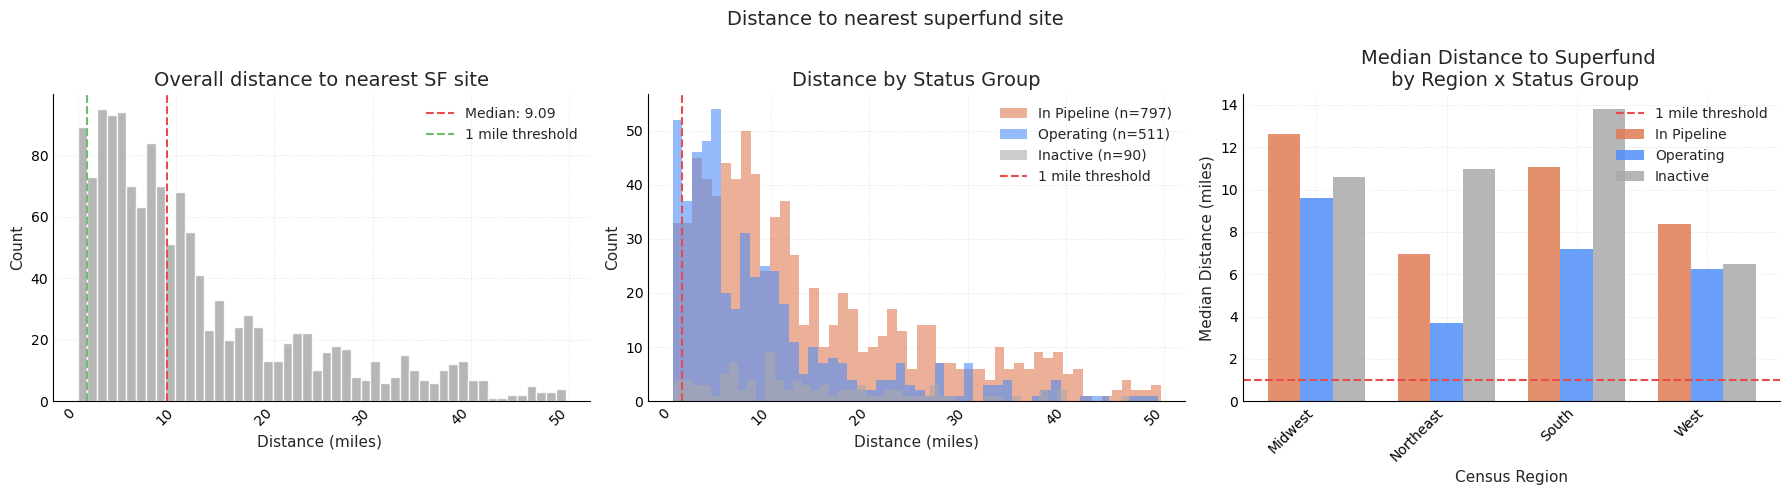

In [60]:
# Distributioin of Distances
# - Overall distribution of `dist_to_nearest_sf_mi` across all DCs
# - Distance distribution broken down by status group
# - Median distance to nearest SF site by census region × status group

fig, axes = plt.subplots(1, 3, figsize=(18,5 ))
fig.suptitle("Distance to nearest superfund site", fontsize=14)

dist_cap = dc_df["dist_to_nearest_sf_mi"].quantile(0.95)
dist_data = dc_df[dc_df["dist_to_nearest_sf_mi"] <= dist_cap]["dist_to_nearest_sf_mi"]
axes[0].hist(
    dist_data,
    bins=50,
    color=COLORS['neutral'],
    alpha=0.85,
    edgecolor='white'
)

axes[0].axvline(
    dc_df['dist_to_nearest_sf_mi'].median(),
    color=COLORS['highlight'],
    linestyle='--',
    linewidth=1.5,
    label=f"Median: {dc_df['dist_to_nearest_sf_mi'].median():.2f}",

)
axes[0].axvline(
    1,
    color=COLORS['superfund'],
    linestyle="--",
    linewidth=1.5,
    label="1 mile threshold"
)
axes[0].set_title("Overall distance to nearest SF site")
axes[0].set_xlabel("Distance (miles) ")
axes[0].set_ylabel("Count")
axes[0].legend()

# distance by status group
status_group_palette = {
    "In Pipeline": COLORS['proposed'],
    "Operating": COLORS['operating'],
    "Inactive": COLORS['neutral']
}

for group, color in status_group_palette.items():
    subset = dc_df[
        (dc_df['status_group'] == group) &
        (dc_df['dist_to_nearest_sf_mi'] <= dist_cap)
    ]['dist_to_nearest_sf_mi']
    axes[1].hist(
        subset,
        bins=50,
        color=color,
        alpha=0.6,
        label=f"{group} (n={len(subset):,})"
    )

axes[1].axvline(
    1,
    color=COLORS['highlight'],
    linestyle="--",
    linewidth=1.5,
    label="1 mile threshold"
)
axes[1].set_title("Distance by Status Group")
axes[1].set_xlabel("Distance (miles)")
axes[1].set_ylabel("Count")
axes[1].legend()

# median distance by census region x status group

region_dist = (
    dc_df.groupby(['census_region', 'status_group'])['dist_to_nearest_sf_mi'].median().unstack()
)
x = np.arange(len(region_dist))
width = 0.25

for i, (group, color) in enumerate(status_group_palette.items()):
    if group in region_dist.columns:
        bars = axes[2].bar(
            x + i * width,
            region_dist[group],
            width,
            label=group,
            color=color,
            alpha=0.85
        )
axes[2].set_title("Median Distance to Superfund \n by Region x Status Group")
axes[2].set_xlabel("Census Region")
axes[2].set_ylabel("Median Distance (miles)")
axes[2].set_xticks(x + width)
axes[2].set_xticklabels(region_dist.index)
axes[2].axhline(
    1,
    color=COLORS['highlight'],
    linestyle='--',
    linewidth=1.5,
    label="1 mile threshold"
)
axes[2].legend()

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [61]:
print("Overall Distance to neraest SF site (miles)")
print(dc_df['dist_to_nearest_sf_mi'].describe().round(3))

print(f"\95th percentile cap used: {dist_cap:.2f}")

print(f"\nMedian distance by status group")
print(dc_df.groupby("status_group")['dist_to_nearest_sf_mi'].median().round(3))

print(f"\n Mean distance by status group")
print(dc_df.groupby("status_group")['dist_to_nearest_sf_mi'].mean().round(3))

print(f"\nMedian distance by region x status group: ")
print(region_dist.round(3))

print(f"\nDistance statsu by status group (full):")
print(dc_df.groupby("status_group")['dist_to_nearest_sf_mi'].describe().round(3))


Overall Distance to neraest SF site (miles)
count    1472.000
mean       15.800
std        22.150
min         0.000
25%         4.258
50%         9.090
75%        19.468
max       267.381
Name: dist_to_nearest_sf_mi, dtype: float64
\95th percentile cap used: 49.77

Median distance by status group
status_group
In Pipeline    10.953
Inactive       10.903
Operating       6.391
Name: dist_to_nearest_sf_mi, dtype: float64

 Mean distance by status group
status_group
In Pipeline    17.955
Inactive       15.121
Operating      12.447
Name: dist_to_nearest_sf_mi, dtype: float64

Median distance by region x status group: 
status_group   In Pipeline  Inactive  Operating
census_region                                  
Midwest             12.616    10.604      9.612
Northeast            6.962    10.994      3.718
South               11.073    13.813      7.173
West                 8.394     6.499      6.237

Distance statsu by status group (full):
              count    mean     std    min    25%  

## 1: Distribution of Distances to Nearest Superfund Site


### Key findings:

**Overall distance distribution:**
| Statistic | Value (miles) |
|---|---|
| Median | 9.09 |
| Mean | 15.80 |
| 25th percentile | 4.26 |
| 75th percentile | 19.47 |
| Max | 267.38 |

Distribution is right-skewed — most DCs are within 10 miles of a SF site
with a long tail of more distant facilities.

**By status group:**
| status_group | Median (mi) | Mean (mi) |
|---|---|---|
| Operating | 6.39 | 12.45 |
| Inactive | 10.90 | 15.12 |
| In Pipeline | 10.95 | 17.96 |

**Counterintuitive finding:** Operating data centers are 4.6 miles closer to superfund sites
sites than data centers that are 'In Pipeline'. There are two possible interpretations for this:
1. Historical siting: Operating data centers were built in industrialized areas
   where SF sites also exist, predating the Executive Order
2. Selection effect: proposed data centers near superfund sites may face more community
   opposition and never reach 'Operating' status

**By region × status group:**
The Northeast shows the strongest contrast. The median distance between data center and superfunding site for 'Operating' data centers is 3.7 miles
while the median distance for 'In Pipeline' data centers are 7.0 miles.

**Note:** — 95th percentile cap for visualization:
Distance histograms are capped at the 95th percentile (~50 miles) to avoid
extreme outlier distortion. Full distribution statistics use uncapped data.

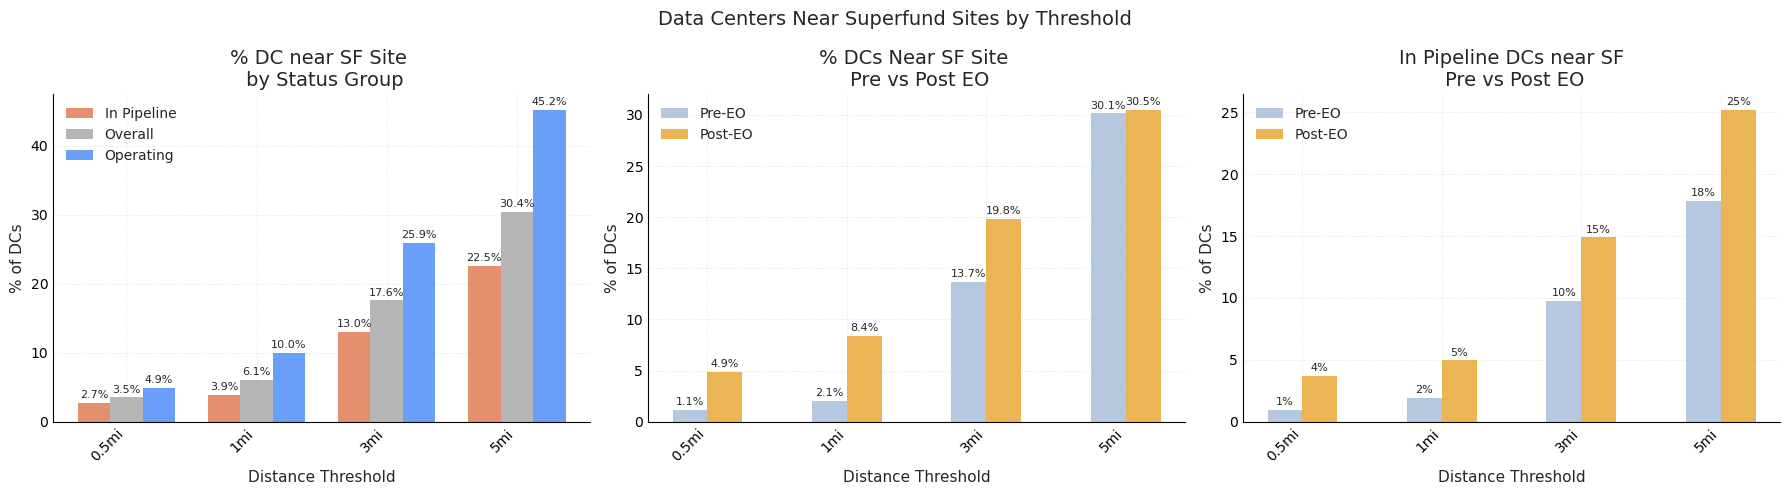

In [62]:
# find binary thresehold
# - % of DCs near SF sites at each threshold by status group
# - % of DCs near SF sites pre vs post EO at each threshold
# - % of In Pipeline DCs near SF sites pre vs post EO at each threshold


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Data Centers Near Superfund Sites by Threshold", fontsize=14)

thresholds = [0.5, 1, 3, 5]
threshold_cols = [f"near_sf_{str(t).replace('.', '_')}mi" for t in thresholds]
threshold_labels = [f"{t}mi" for t in thresholds]

# % near SF at each threshold + by status group
overall_pct = [dc_df[col].mean() * 100 for col in threshold_cols]
pipeline_pct = [
    dc_df[dc_df['status_group'] == "In Pipeline"][col].mean() * 100
    for col in threshold_cols
]

operating_pct = [
    dc_df[dc_df['status_group'] == "Operating"][col].mean() * 100
    for col in threshold_cols
]

x = np.arange(len(thresholds))
width = 0.25
axes[0].bar(x - width, pipeline_pct, width, label = "In Pipeline", color=COLORS['proposed'], alpha=0.85)
axes[0].bar(x, overall_pct, width, label="Overall", color=COLORS['neutral'], alpha=0.85)
axes[0].bar(x + width, operating_pct, width, label='Operating', color=COLORS['operating'], alpha=0.85)
axes[0].set_title("% DC near SF Site \n by Status Group")
axes[0].set_xlabel("Distance Threshold")
axes[0].set_ylabel("% of DCs")
axes[0].set_xticks(x)
axes[0].set_xticklabels(threshold_labels)
axes[0].legend()

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.1f%%", fontsize=8, padding=2)

# % near SF at each threshold by pre / post EO
pre_pct = [
    dc_df[dc_df['post_eo'] == False][col].mean() * 100
    for col in threshold_cols
]
post_pct = [
    dc_df[dc_df['post_eo'] == True][col].mean() * 100
    for col in threshold_cols
]
axes[1].bar(x - width / 2, pre_pct, width, label = "Pre-EO", color=COLORS['pre_eo'], alpha=0.85)
axes[1].bar(x + width / 2, post_pct, width, label = "Post-EO", color=COLORS['post_eo'], alpha=0.85)
axes[1].set_title("% DC near SF Site\n Pre- vs Post EO")
axes[1].set_title("% DCs Near SF Site \n Pre vs Post EO")
axes[1].set_xlabel("Distance Threshold")
axes[1].set_ylabel("% of DCs")
axes[1].set_xticks(x)
axes[1].set_xticklabels(threshold_labels)
axes[1].legend()
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f%%", fontsize=8, padding=2)

# in pipeline near SF pre / post EO

pipeline_pre_pct = [
    dc_df[
        (dc_df['status_group'] == 'In Pipeline') &
        (dc_df['post_eo'] == False)
    ][col].mean() * 100 for col in threshold_cols
]

pipeline_post_pct =  [
    dc_df[
        (dc_df['status_group'] == 'In Pipeline') &
        (dc_df['post_eo'] == True)
    ][col].mean() * 100 for col in threshold_cols
]
axes[2].bar(x - width / 2, pipeline_pre_pct, width, label="Pre-EO", color=COLORS["pre_eo"], alpha=0.85)
axes[2].bar(x + width / 2, pipeline_post_pct, width, label = "Post-EO", color=COLORS['post_eo'], alpha=0.85)
axes[2].set_title("In Pipeline DCs near SF\n Pre vs Post EO")
axes[2].set_xlabel("Distance Threshold")
axes[2].set_ylabel("% of DCs")
axes[2].set_xticks(x)
axes[2].set_xticklabels(threshold_labels)
axes[2].legend()

for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%1.f%%", fontsize=8, padding=2)

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation = 45, ha="right")
plt.tight_layout()
plt.show()

In [63]:
print("% of DCs near SF Site by threshold: ")
summary = pd.DataFrame({
    "threshold_mi": thresholds,
    "overall_pct": overall_pct,
    "pipeline_pct": pipeline_pct,
    "operating_pct": operating_pct,
    "pre_eo_pct": pre_pct,
    "post_eo_pct": post_pct,
    "pipeline_pre_pct": pipeline_pre_pct,
    "pipeline_post_pct": pipeline_post_pct
}).round(2)

% of DCs near SF Site by threshold: 


In [64]:
summary

,threshold_mi,overall_pct,pipeline_pct,operating_pct,pre_eo_pct,post_eo_pct,pipeline_pre_pct,pipeline_post_pct
0,0.5,3.53,2.70,4.91,1.12,4.90,0.97,3.68
1,1.0,6.11,3.87,10.02,2.06,8.42,1.95,4.96
2,3.0,17.60,13.03,25.90,13.67,19.83,9.74,14.89
3,5.0,30.37,22.54,45.18,30.15,30.49,17.86,25.18


In [65]:
print(f"\nRaw counts at 1 mile threshold:")
for group in ["In Pipeline", "Operating", "Inactive"]:
    subset = dc_df[dc_df["status_group"] == group]
    n_near = subset["near_sf_1mi"].sum()
    print(f"  {group}: {n_near:,} of {len(subset):,} "
          f"({n_near/len(subset)*100:.1f}%)")



Raw counts at 1 mile threshold:
  In Pipeline: 33 of 852 (3.9%)
  Operating: 53 of 529 (10.0%)
  Inactive: 4 of 91 (4.4%)


In [66]:
print(f"\nRaw counts at 1 mile threshold pre/post EO (In Pipeline only):")
for post in [False, True]:
    label  = "Post-EO" if post else "Pre-EO"
    subset = dc_df[
        (dc_df["status_group"] == "In Pipeline") &
        (dc_df["post_eo"] == post)
    ]
    n_near = subset["near_sf_1mi"].sum()
    print(f"  {label}: {n_near:,} of {len(subset):,} "
          f"({n_near/len(subset)*100:.1f}%)")


Raw counts at 1 mile threshold pre/post EO (In Pipeline only):
  Pre-EO: 6 of 308 (1.9%)
  Post-EO: 27 of 544 (5.0%)


## 2: Binary Threshold Analysis


### Key findings:

**By status group:**
| Threshold | In Pipeline | Overall | Operating |
|---|---|---|---|
| 0.5 mi | 2.7% | 3.5% | 4.9% |
| 1 mi | 3.9% | 6.1% | 10.0% |
| 3 mi | 13.0% | 17.6% | 25.9% |
| 5 mi | 22.5% | 30.4% | 45.2% |

Operating DCs are 2.6x more likely to be within 1 mile of a SF site than
In Pipeline DCs.

**Pre vs Post EO (all DCs):**
| Threshold | Pre-EO | Post-EO |
|---|---|---|
| 0.5 mi | 1.1% | 4.9% |
| 1 mi | 2.0% | 8.2% |
| 3 mi | 13.7% | 19.8% |
| 5 mi | 30.1% | 30.4% |




**In Pipeline pre vs post EO — primary finding:**
| Threshold | Pre-EO | Post-EO | Change |
|---|---|---|---|
| 0.5 mi | 1.0% | 3.7% | +2.1pp |
| 1 mi | 2.0% | 5.0% | +2.6pp |
| 3 mi | 9.74% | 15.0% | +8.2pp |
| 5 mi | 17.86% | 25.1% | +9.7pp |

Raw counts at 1 mile threshold:
- Pre-EO In Pipeline: 6 of 308 (2.0%)
- Post-EO In Pipeline: 27 of 544 (4.9%)


### Decision — primary reporting threshold:
While 1 mile has the strongest scientific precedent (EPA assessments, MIT study),
the absolute N is small (27 post-EO). **3 miles is the primary reporting
threshold** due to better statistical power. 1 mile is reported as the
conservative estimate. Both are presented in the findings.

In [67]:
# Verify the 28 post-EO In Pipeline within 1 mile
flagged = dc_df[
    (dc_df["status_group"] == "In Pipeline") &
    (dc_df["post_eo"] == True) &
    (dc_df["near_sf_1mi"] == 1)
][["facility_name", "city", "state", "nearest_sf_name",
   "dist_to_nearest_sf_mi", "date_created"]]
print(flagged.sort_values("dist_to_nearest_sf_mi"))

                                          facility_name  \
3              Western Hospitality Partners Data Center   
40        Data center: Edwards Air Force Base (7 sites)   
238        Data center: Robins Air Force Base (3 sites)   
385                          Wildwood Ranch Data Center   
1450                                 Festus Data Center   
1470                               Sentinel data center   
1410                               Sarcoxie Data Center   
63                             CoreSite DE3 Data Center   
456                            Zenith Volts Data Center   
1361                                    IBM Data Center   
46                                              Equinix   
1328                        Menlo Equities Data Centere   
51                                         CoreSite SV9   
1336           Walsh Bowers Technology Center: CoreSite   
443   Data center: Joint Base McGuire-Dix-Lakehurst ...   
1288                                         Atlas Agro 

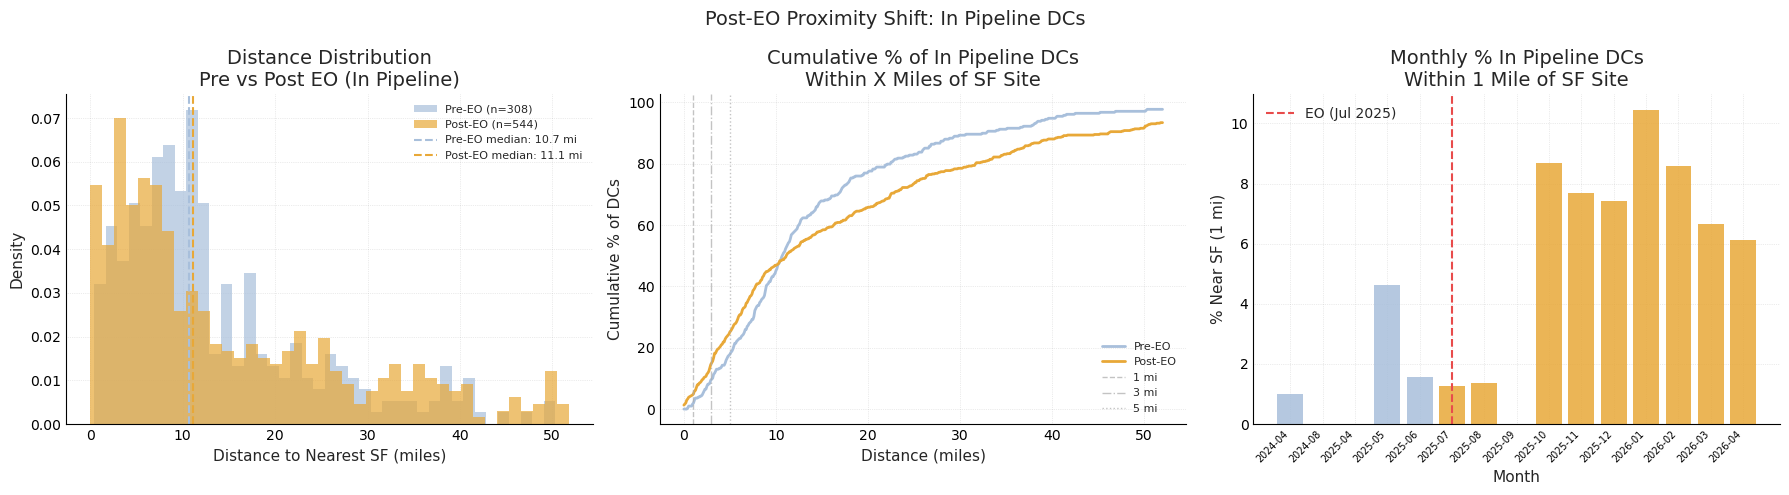

In [68]:
# post-EO proximity shift
# - Distance distribution pre vs post EO for In Pipeline DCs only
# - Cumulative % of In Pipeline DCs within X miles of SF site
# - Monthly % of In Pipeline DCs within 1 mile (months with n≥5 only)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Post-EO Proximity Shift: In Pipeline DCs", fontsize=14)

# filter to in pipeline

pipeline = dc_df[dc_df["status_group"] == "In Pipeline"].copy()
pipeline_pre  = pipeline[pipeline["post_eo"] == False]
pipeline_post = pipeline[pipeline["post_eo"] == True]


# distribution of distances pre vs post eo
dist_cap = pipeline["dist_to_nearest_sf_mi"].quantile(0.95)

axes[0].hist(
    pipeline_pre[pipeline_pre["dist_to_nearest_sf_mi"] <= dist_cap]
    ["dist_to_nearest_sf_mi"],
    bins=40,
    color=COLORS["pre_eo"],
    alpha=0.7,
    label=f"Pre-EO (n={len(pipeline_pre):,})",
    density=True,
)
axes[0].hist(
    pipeline_post[pipeline_post["dist_to_nearest_sf_mi"] <= dist_cap]
    ["dist_to_nearest_sf_mi"],
    bins=40,
    color=COLORS["post_eo"],
    alpha=0.7,
    label=f"Post-EO (n={len(pipeline_post):,})",
    density=True,
)
axes[0].axvline(
    pipeline_pre["dist_to_nearest_sf_mi"].median(),
    color=COLORS["pre_eo"],
    linestyle="--",
    linewidth=1.5,
    label=f"Pre-EO median: {pipeline_pre['dist_to_nearest_sf_mi'].median():.1f} mi",
)
axes[0].axvline(
    pipeline_post["dist_to_nearest_sf_mi"].median(),
    color=COLORS["post_eo"],
    linestyle="--",
    linewidth=1.5,
    label=f"Post-EO median: {pipeline_post['dist_to_nearest_sf_mi'].median():.1f} mi",
)
axes[0].set_title("Distance Distribution\nPre vs Post EO (In Pipeline)")
axes[0].set_xlabel("Distance to Nearest SF (miles)")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)

# cumulative distrbution (what percent falls within x miles)
dist_range = np.linspace(0, dist_cap, 500)

cdf_pre  = [
    (pipeline_pre["dist_to_nearest_sf_mi"] <= d).mean() * 100
    for d in dist_range
]
cdf_post = [
    (pipeline_post["dist_to_nearest_sf_mi"] <= d).mean() * 100
    for d in dist_range
]

axes[1].plot(dist_range, cdf_pre,  color=COLORS["pre_eo"],
             linewidth=2, label="Pre-EO")
axes[1].plot(dist_range, cdf_post, color=COLORS["post_eo"],
             linewidth=2, label="Post-EO")

# Mark key thresholds
for mi, ls in zip([1, 3, 5], ["--", "-.", ":"]):
    axes[1].axvline(mi, color=COLORS["neutral"],
                    linestyle=ls, linewidth=1, alpha=0.7, label=f"{mi} mi")

axes[1].set_title("Cumulative % of In Pipeline DCs\nWithin X Miles of SF Site")
axes[1].set_xlabel("Distance (miles)")
axes[1].set_ylabel("Cumulative % of DCs")
axes[1].legend(fontsize=8)

# % near SF at each threshold pre / post EO over time

pipeline["month"] = pipeline["date_created"].dt.to_period("M")

monthly_near = (
    pipeline.groupby("month")
    .agg(
        total=("near_sf_1mi", "count"),
        near_sf=("near_sf_1mi", "sum"),
    )
    .assign(pct_near=lambda x: x["near_sf"] / x["total"] * 100)
)

monthly_near = monthly_near[monthly_near["total"] >= 5]

axes[2].bar(
    range(len(monthly_near)),
    monthly_near["pct_near"],
    color=[
        COLORS["post_eo"] if str(p) >= "2025-07" else COLORS["pre_eo"]
        for p in monthly_near.index
    ],
    alpha=0.85,
    width=0.8,
)

eo_idx = [i for i, p in enumerate(monthly_near.index)
          if str(p) == "2025-07"]
if eo_idx:
    axes[2].axvline(
        eo_idx[0],
        color=COLORS["highlight"],
        linestyle="--",
        linewidth=1.5,
        label="EO (Jul 2025)",
    )

axes[2].set_title("Monthly % In Pipeline DCs\nWithin 1 Mile of SF Site")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("% Near SF (1 mi)")
axes[2].set_xticks(range(len(monthly_near)))
axes[2].set_xticklabels(
    [str(p) for p in monthly_near.index],
    rotation=45, ha="right", fontsize=7
)
axes[2].legend()

plt.tight_layout()
plt.show()




In [69]:
print("In Pipeline distance stats pre vs post EO:")
print(pd.DataFrame({
    "Pre-EO" : pipeline_pre["dist_to_nearest_sf_mi"].describe(),
    "Post-EO": pipeline_post["dist_to_nearest_sf_mi"].describe(),
}).round(3))

print(f"\nMedian shift: "
      f"{pipeline_pre['dist_to_nearest_sf_mi'].median():.2f} → "
      f"{pipeline_post['dist_to_nearest_sf_mi'].median():.2f} miles")

print(f"\nCumulative % within thresholds — In Pipeline pre vs post EO:")
for mi in [0.5, 1, 3, 5]:
    pre_pct  = (pipeline_pre["dist_to_nearest_sf_mi"]  <= mi).mean() * 100
    post_pct = (pipeline_post["dist_to_nearest_sf_mi"] <= mi).mean() * 100
    print(f"  {mi} mi: Pre-EO {pre_pct:.1f}% → Post-EO {post_pct:.1f}% "
          f"(+{post_pct - pre_pct:.1f}pp)")

print(f"\nMonthly breakdown (months with n≥5):")
print(monthly_near.to_string())

In Pipeline distance stats pre vs post EO:
        Pre-EO  Post-EO
count  308.000  544.000
mean    15.272   19.474
std     17.427   23.471
min      0.394    0.000
25%      6.584    4.971
50%     10.703   11.114
75%     18.068   25.730
max    215.097  190.201

Median shift: 10.70 → 11.11 miles

Cumulative % within thresholds — In Pipeline pre vs post EO:
  0.5 mi: Pre-EO 1.0% → Post-EO 3.7% (+2.7pp)
  1 mi: Pre-EO 1.9% → Post-EO 5.0% (+3.0pp)
  3 mi: Pre-EO 9.7% → Post-EO 14.9% (+5.1pp)
  5 mi: Pre-EO 17.9% → Post-EO 25.2% (+7.3pp)

Monthly breakdown (months with n≥5):
         total  near_sf   pct_near
month                             
2024-04    101        1   0.990099
2024-08      6        0   0.000000
2025-04      6        0   0.000000
2025-05     65        3   4.615385
2025-06     64        1   1.562500
2025-07     79        1   1.265823
2025-08    148        2   1.351351
2025-09     68        0   0.000000
2025-10     46        4   8.695652
2025-11     39        3   7.692308
2025-

## 3: Post-EO Proximity Shift

### Key findings:

**Distance distribution:**
| Statistic | Pre-EO | Post-EO |
|---|---|---|
| Count | 308 | 544 |
| Median | 10.70 mi | 11.1 mi |
| 25th percentile | 6.58 mi | 4.97 mi |
| Mean | 15.27 mi | 19.47 mi |

- The median distance between data centers and superfund sites is nearly identical before and after the EO.
- However, the 25th percentile dropped 1.6 miles after the EO so there is an effect concentrated in the left tail

**Cumulative distribution:**
- The CDF curve for data after the EO sits consistently above the CDF  curve for data before the EO at every
distance up to ~25 miles.  This means that meaning at any given distance, a higher % of
proposals are within that distance of a SF site after the Executive Order.
- The gap is more pronounced at 3-5 miles.
 - The curves converge around 25-30 miles, suggesting the effect of the EO is concentrated in in ranges of close proximity

**Monthly trend:**
| Period | % within 1 mile | Note |
|---|---|---|
| 2024-04 | 1.0% | Bulk entry event — 101 proposals |
| 2025-05 to 2025-07 | 1.3-4.6% | Pre/transition period |
| 2025-08 | 1.4% | Largest single month (148 proposals) |
| 2025-09 | 0.0% | Dip — unclear cause |
| 2025-10 onward | 6.7-10.4% | Sustained elevation |

**Important observation:**
- If there is an effect of the EO, it doesn't emerge immediately in August 2025.  It emerged in October 2025, reflecting a lag in permitting timelines, developer response time or data entry due to crowdsourced data.

**Notes:** Consider how to handle days with bulk data entries (`days_since_eo`)

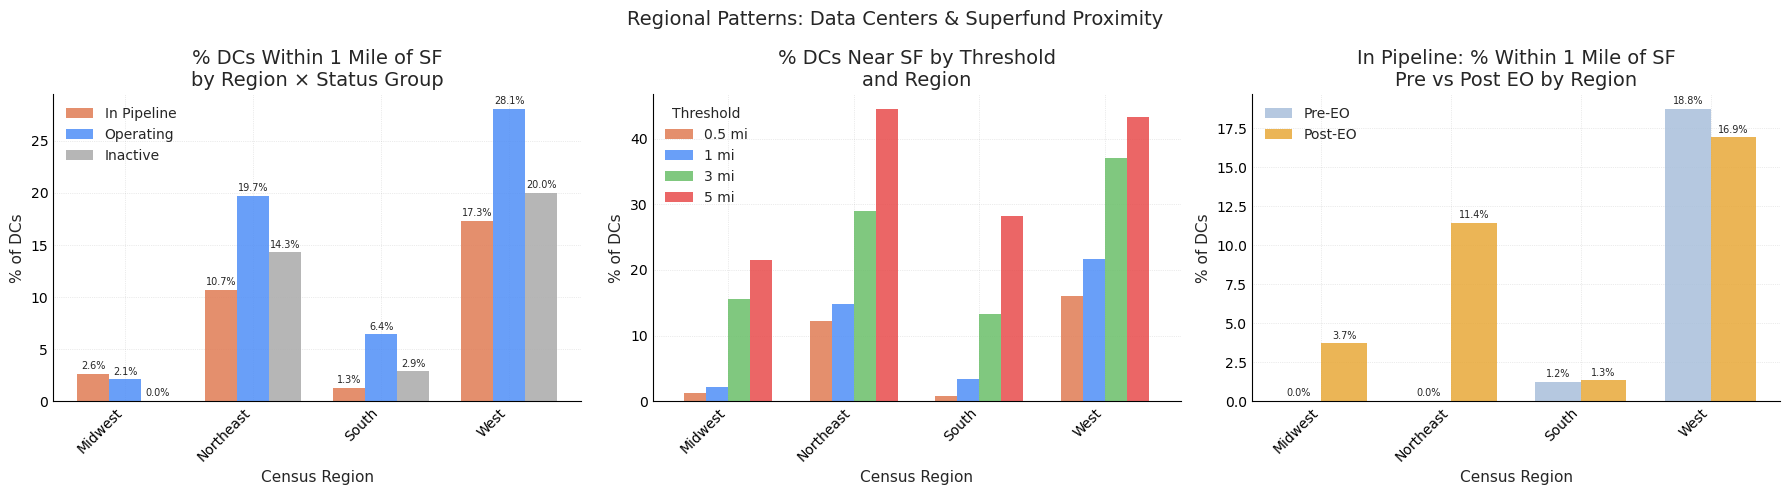

In [70]:
# regional patterns
# - % of DCs within 1 mile of SF by region × status group
# - % of DCs near SF by threshold and region
# - In Pipeline % within 1 mile pre vs post EO by region



fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Regional Patterns: Data Centers & Superfund Proximity", fontsize=14)

# % near SF at 1 mile by region × status group
region_status_pct = (
    dc_df.groupby(["census_region", "status_group"])["near_sf_1mi"]
    .mean() * 100
).unstack()

x     = np.arange(len(region_status_pct))
width = 0.25

status_group_palette = {
    "In Pipeline": COLORS["proposed"],
    "Operating":   COLORS["operating"],
    "Inactive":    COLORS["neutral"],
}

for i, (group, color) in enumerate(status_group_palette.items()):
    if group in region_status_pct.columns:
        bars = axes[0].bar(
            x + i * width,
            region_status_pct[group],
            width,
            label=group,
            color=color,
            alpha=0.85,
        )
        axes[0].bar_label(bars, fmt="%.1f%%", fontsize=7, padding=2)

axes[0].set_title("% DCs Within 1 Mile of SF\nby Region × Status Group")
axes[0].set_xlabel("Census Region")
axes[0].set_ylabel("% of DCs")
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(region_status_pct.index)
axes[0].legend()

# % near SF at each threshold by region
threshold_cols = [f"near_sf_{str(t).replace('.', '_')}mi"
                  for t in [0.5, 1, 3, 5]]
threshold_labels = ["0.5 mi", "1 mi", "3 mi", "5 mi"]

region_threshold = (
    dc_df.groupby("census_region")[threshold_cols]
    .mean() * 100
)
region_threshold.columns = threshold_labels

region_threshold.plot(
    kind="bar",
    ax=axes[1],
    color=[COLORS["proposed"], COLORS["operating"],
           COLORS["superfund"], COLORS["highlight"]],
    alpha=0.85,
    width=0.7,
)
axes[1].set_title("% DCs Near SF by Threshold\nand Region")
axes[1].set_xlabel("Census Region")
axes[1].set_ylabel("% of DCs")
axes[1].legend(title="Threshold")

# Pre/Post EO proximity shift by region for in pipeline only

pipeline = dc_df[dc_df["status_group"] == "In Pipeline"]

region_eo = (
    pipeline.groupby(["census_region", "post_eo"])["near_sf_1mi"]
    .mean() * 100
).unstack()
region_eo.columns = ["Pre-EO", "Post-EO"]

x     = np.arange(len(region_eo))
width = 0.35

bars_pre  = axes[2].bar(
    x - width / 2,
    region_eo["Pre-EO"],
    width,
    label="Pre-EO",
    color=COLORS["pre_eo"],
    alpha=0.85,
)
bars_post = axes[2].bar(
    x + width / 2,
    region_eo["Post-EO"],
    width,
    label="Post-EO",
    color=COLORS["post_eo"],
    alpha=0.85,
)

axes[2].bar_label(bars_pre,  fmt="%.1f%%", fontsize=7, padding=2)
axes[2].bar_label(bars_post, fmt="%.1f%%", fontsize=7, padding=2)

axes[2].set_title("In Pipeline: % Within 1 Mile of SF\nPre vs Post EO by Region")
axes[2].set_xlabel("Census Region")
axes[2].set_ylabel("% of DCs")
axes[2].set_xticks(x)
axes[2].set_xticklabels(region_eo.index)
axes[2].legend()

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()



In [71]:
print("% within 1 mile by region × status group:")
print(region_status_pct.round(2))

print(f"\n% near SF by threshold and region:")
print(region_threshold.round(2))

print(f"\nIn Pipeline % within 1 mile pre/post EO by region:")
print(region_eo.round(2))

print(f"\nIn Pipeline % within 3 miles pre/post EO by region:")
region_eo_3mi = (
    pipeline.groupby(["census_region", "post_eo"])["near_sf_3mi"]
    .mean() * 100
).unstack()
region_eo_3mi.columns = ["Pre-EO", "Post-EO"]
region_eo_3mi["shift_pp"] = region_eo_3mi["Post-EO"] - region_eo_3mi["Pre-EO"]
print(region_eo_3mi.round(2))

% within 1 mile by region × status group:
status_group   In Pipeline  Inactive  Operating
census_region                                  
Midwest               2.63      0.00       2.08
Northeast            10.67     14.29      19.70
South                 1.29      2.86       6.42
West                 17.28     20.00      28.07

% near SF by threshold and region:
               0.5 mi   1 mi   3 mi   5 mi
census_region                             
Midwest          1.27   2.11  15.61  21.52
Northeast       12.26  14.84  29.03  44.52
South            0.75   3.31  13.23  28.28
West            16.08  21.68  37.06  43.36

In Pipeline % within 1 mile pre/post EO by region:
               Pre-EO  Post-EO
census_region                 
Midwest          0.00     3.70
Northeast        0.00    11.43
South            1.23     1.33
West            18.75    16.92

In Pipeline % within 3 miles pre/post EO by region:
               Pre-EO  Post-EO  shift_pp
census_region                           
Mid

## Beat 4: Regional Patterns

### Key findings:

**% within 1 mile by region × status group:**
| Region | In Pipeline | Operating |
|---|---|---|
| West | 17.3% | 28.1% |
| Northeast | 10.7% | 19.7% |
| Midwest | 2.6% | 2.1% |
| South | 1.3% | 6.4% |

- the West and Northeast have dramatically higher SF proximity than the
South and Midwest (this mmight be counterintuitive given the South dominates in data center volume)

**Pre vs post EO shift by region (In Pipeline, 3 miles):**
| Region | Pre-EO | Post-EO | Shift | Reliable? |
|---|---|---|---|---|
| Midwest | 9.09% | 16.67% | +7.58pp | ✓ Yes |
| South | 7.82% | 8.31% | +.49pp | ✓ Yes |
| West | 43.75% | 27.69% | -16.06pp | ⚠ Small pre-EO N |
| Northeast | 0.0% | 28.57% | +28.57pp | ✗ Pre-EO N=1 |


**West reversal:** Post-EO In Pipeline DCs in the West are actually moving
away from SF sites. However pre-EO West In Pipeline N=12, making this finding
unreliable. Noted but not reported as a primary finding.

**Northeast:** Pre-EO N=1 — completely unreliable. Excluded from causal analysis,
reported descriptively only.

### Decision — regional causal analysis scope:
- Primary: South and Midwest (adequate N on both sides of EO)
- Secondary: West (reported with small N caveat)
- Excluded: Northeast (pre-EO N=1)

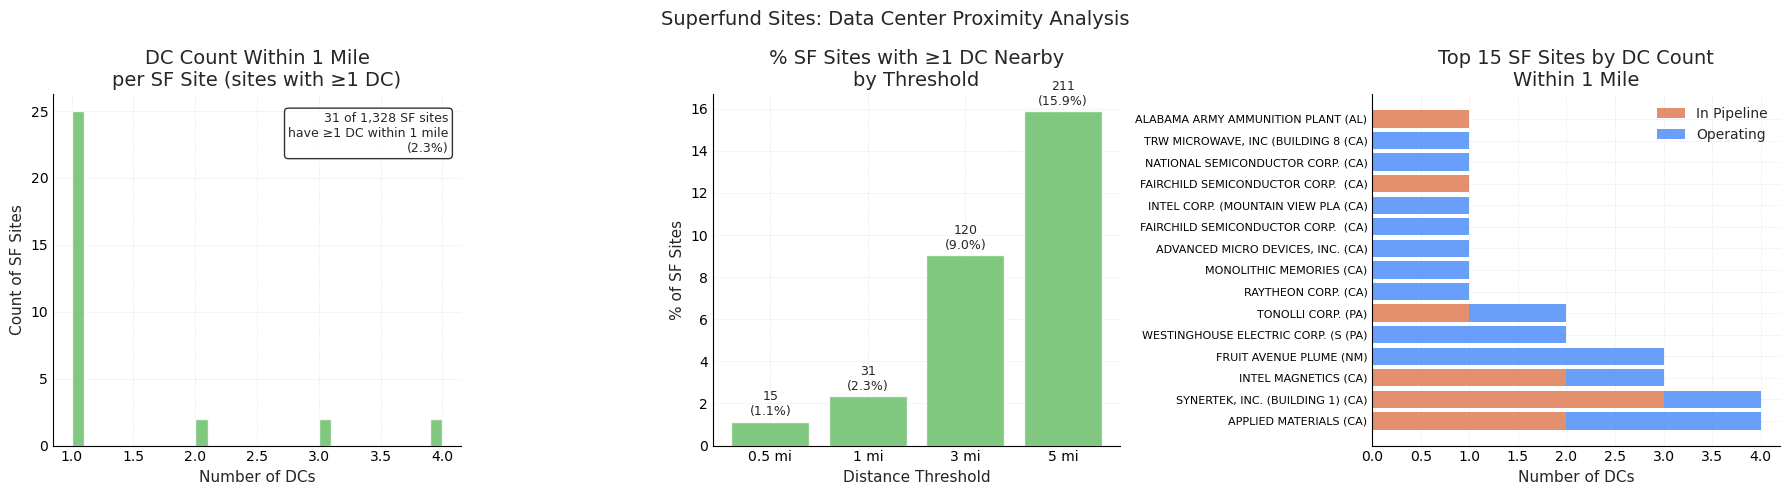

In [72]:
# SF centered
# - Distribution of DC count within 1 mile per SF site
# - % of SF sites with ≥1 DC nearby at each threshold
# - Top 15 SF sites by DC count within 1 mile

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Superfund Sites: Data Center Proximity Analysis", fontsize=14)

# distribution of dc_count within 1 mile per SF site
dc_counts = sf_df["dc_count_within_1mi"]

axes[0].hist(
    dc_counts[dc_counts > 0],
    bins=30,
    color=COLORS["superfund"],
    alpha=0.85,
    edgecolor="white",
)
axes[0].set_title("DC Count Within 1 Mile\nper SF Site (sites with ≥1 DC)")
axes[0].set_xlabel("Number of DCs")
axes[0].set_ylabel("Count of SF Sites")

# annotate total
n_with_dc = (dc_counts > 0).sum()
n_total   = len(dc_counts)
axes[0].text(
    0.97, 0.95,
    f"{n_with_dc:,} of {n_total:,} SF sites\nhave ≥1 DC within 1 mile\n({n_with_dc/n_total*100:.1f}%)",
    transform=axes[0].transAxes,
    ha="right", va="top", fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

# SF sites with most data centers at each threshold
threshold_cols_sf = [
    f"dc_count_within_{str(t).replace('.', '_')}mi"
    for t in [0.5, 1, 3, 5]
]
threshold_labels  = ["0.5 mi", "1 mi", "3 mi", "5 mi"]

pct_sf_with_dc = [
    (sf_df[col] > 0).mean() * 100
    for col in threshold_cols_sf
]
n_sf_with_dc = [
    (sf_df[col] > 0).sum()
    for col in threshold_cols_sf
]

bars = axes[1].bar(
    threshold_labels,
    pct_sf_with_dc,
    color=COLORS["superfund"],
    alpha=0.85,
    edgecolor="white",
)
axes[1].set_title("% SF Sites with ≥1 DC Nearby\nby Threshold")
axes[1].set_xlabel("Distance Threshold")
axes[1].set_ylabel("% of SF Sites")

for bar, n in zip(bars, n_sf_with_dc):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{n:,}\n({bar.get_height():.1f}%)",
        ha="center", fontsize=9,
    )

# SF sites with highest DC count within one mile
top_sf = (
    sf_df[sf_df["dc_count_within_1mi"] > 0]
    [["SITE_NAME", "STATE_CODE", "dc_count_within_1mi",
      "pipeline_count_within_1mi", "operating_count_within_1mi"]]
    .sort_values("dc_count_within_1mi", ascending=False)
    .head(15)
)

y = np.arange(len(top_sf))
axes[2].barh(
    y,
    top_sf["pipeline_count_within_1mi"],
    color=COLORS["proposed"],
    alpha=0.85,
    label="In Pipeline",
)
axes[2].barh(
    y,
    top_sf["operating_count_within_1mi"],
    left=top_sf["pipeline_count_within_1mi"],
    color=COLORS["operating"],
    alpha=0.85,
    label="Operating",
)
axes[2].set_yticks(y)
axes[2].set_yticklabels(
    [f"{row.SITE_NAME[:30]} ({row.STATE_CODE})"
     for row in top_sf.itertuples()],
    fontsize=8,
)
axes[2].set_title("Top 15 SF Sites by DC Count\nWithin 1 Mile")
axes[2].set_xlabel("Number of DCs")
axes[2].legend()

plt.tight_layout()
plt.show()


In [73]:
print("SF sites with ≥1 DC by threshold:")
for col, label, n, pct in zip(
    threshold_cols_sf, threshold_labels, n_sf_with_dc, pct_sf_with_dc
):
    print(f"  {label}: {n:,} SF sites ({pct:.1f}%)")

print(f"\ndc_count_within_1mi distribution:")
print(sf_df["dc_count_within_1mi"].describe().round(2))

print(f"\nTop 15 SF sites by DC count within 1 mile:")
print(top_sf.to_string(index=False))

print(f"\nLinear sites (river/stream) with DCs within 1 mile:")
linear_with_dc = sf_df[
    (sf_df["linear_site"] == 1) &
    (sf_df["dc_count_within_1mi"] > 0)
][["SITE_NAME", "STATE_CODE", "dc_count_within_1mi"]]
print(f"  Count: {len(linear_with_dc)}")
if len(linear_with_dc) > 0:
    print(linear_with_dc.to_string(index=False))

SF sites with ≥1 DC by threshold:
  0.5 mi: 15 SF sites (1.1%)
  1 mi: 31 SF sites (2.3%)
  3 mi: 120 SF sites (9.0%)
  5 mi: 211 SF sites (15.9%)

dc_count_within_1mi distribution:
count    1328.00
mean        0.03
std         0.25
min         0.00
25%         0.00
50%         0.00
75%         0.00
max         4.00
Name: dc_count_within_1mi, dtype: float64

Top 15 SF sites by DC count within 1 mile:
                                           SITE_NAME STATE_CODE  dc_count_within_1mi  pipeline_count_within_1mi  operating_count_within_1mi
                                   APPLIED MATERIALS         CA                    4                          2                           2
                         SYNERTEK, INC. (BUILDING 1)         CA                    4                          3                           1
                                     INTEL MAGNETICS         CA                    3                          2                           1
                                  FR

In [74]:
# Check linear site geometry types
print(sf_df[sf_df["linear_site"] == 1].geometry.geom_type.value_counts())

# Compare centroid locations for a known linear site
test_site = sf_df[sf_df["SITE_NAME"] == "APPLIED MATERIALS"]
print(test_site[["SITE_NAME", "GIS_AREA", "GIS_AREA_UNITS",
                  "linear_site", "geometry"]].T)

# How many of our 31 SF sites within 1mi are linear?
sf_with_dc = sf_df[sf_df["dc_count_within_1mi"] > 0]
print(f"\nOf 31 SF sites with DCs within 1mi:")
print(f"  Linear sites: {sf_with_dc['linear_site'].sum()}")
print(f"  Non-linear:   {(sf_with_dc['linear_site'] == 0).sum()}")

MultiPolygon    109
Name: count, dtype: int64
                                                               81
SITE_NAME                                       APPLIED MATERIALS
GIS_AREA                                                  0.00225
GIS_AREA_UNITS                                              Miles
linear_site                                                     1
geometry        MULTIPOLYGON (((-121.97786838391899 37.3765635...

Of 31 SF sites with DCs within 1mi:
  Linear sites: 13
  Non-linear:   18


In [75]:
# How large is the Applied Materials polygon in degrees?
test_site = sf_df[sf_df["SITE_NAME"] == "APPLIED MATERIALS"].iloc[0]
print(f"Geometry bounds: {test_site.geometry.bounds}")
print(f"Geometry area (degrees²): {test_site.geometry.area:.8f}")
print(f"GIS_AREA raw: {test_site['GIS_AREA']} {test_site['GIS_AREA_UNITS']}")

# Compare to a known non-linear site of similar size
non_linear = sf_df[
    (sf_df["linear_site"] == 0) &
    (sf_df["GIS_AREA_ACRES"] < 5)
].iloc[0]
print(f"\nNon-linear comparison site: {non_linear['SITE_NAME']}")
print(f"Geometry bounds: {non_linear.geometry.bounds}")
print(f"GIS_AREA_ACRES: {non_linear['GIS_AREA_ACRES']:.2f}")

Geometry bounds: (-121.979470975805, 37.37648353788509, -121.97786838391899, 37.378748030797084)
Geometry area (degrees²): 0.00000323
GIS_AREA raw: 0.0022497915927297 Miles

Non-linear comparison site: ALABAMA PLATING COMPANY, INC.
Geometry bounds: (-86.40536921241912, 33.39819756876294, -86.402808842554, 33.39941794877941)
GIS_AREA_ACRES: 4.90


## 5: Superfund-Centric Analysis


### Key findings:

**SF sites with DCs nearby:**
| Threshold | SF sites with ≥1 DC | % of Final NPL sites |
|---|---|---|
| 0.5 mi | 15 | 1.1% |
| 1 mi | 31 | 2.3% |
| 3 mi | 120 | 9.0% |
| 5 mi | 211 | 15.9% |

Most superfund sites have just one data center nearby, some have a handful have 2-4.
The mean count of data centers within 1 mile is 0.03 — proximity is sparse but not zero.

**Top 15 SF sites by DC count within 1 mile:**
California semiconductor legacy sites dominate — Applied Materials and
Synertek (4 DCs each), Intel Magnetics (3), AMD, Fairchild, Intel Corp,
Raytheon, Monolithic Memories, National Semiconductor, TRW Microwave (1 each).
Non-CA sites: Fruit Avenue Plume NM (3), Westinghouse PA (2), Tonolli PA (2),
Alabama Army Ammunition Plant AL (1).


### Georgia finding — flagged for follow-up:
- 22 centers within 1 mile of SF sites in Georgia — more than any other state.
- 20 of the data centers within one mile of a superfund site are 'Operating'.


### California finding — connects to existing research:
- There is a cluster of semiconducter sites in Silicon Valley semiconductor (Intel, AMD, Applied
Materials, Fairchild).  This corresponds and supports the Kapor Foundation findings cited in our background — legacy contamination sites adjacent to current DC development.

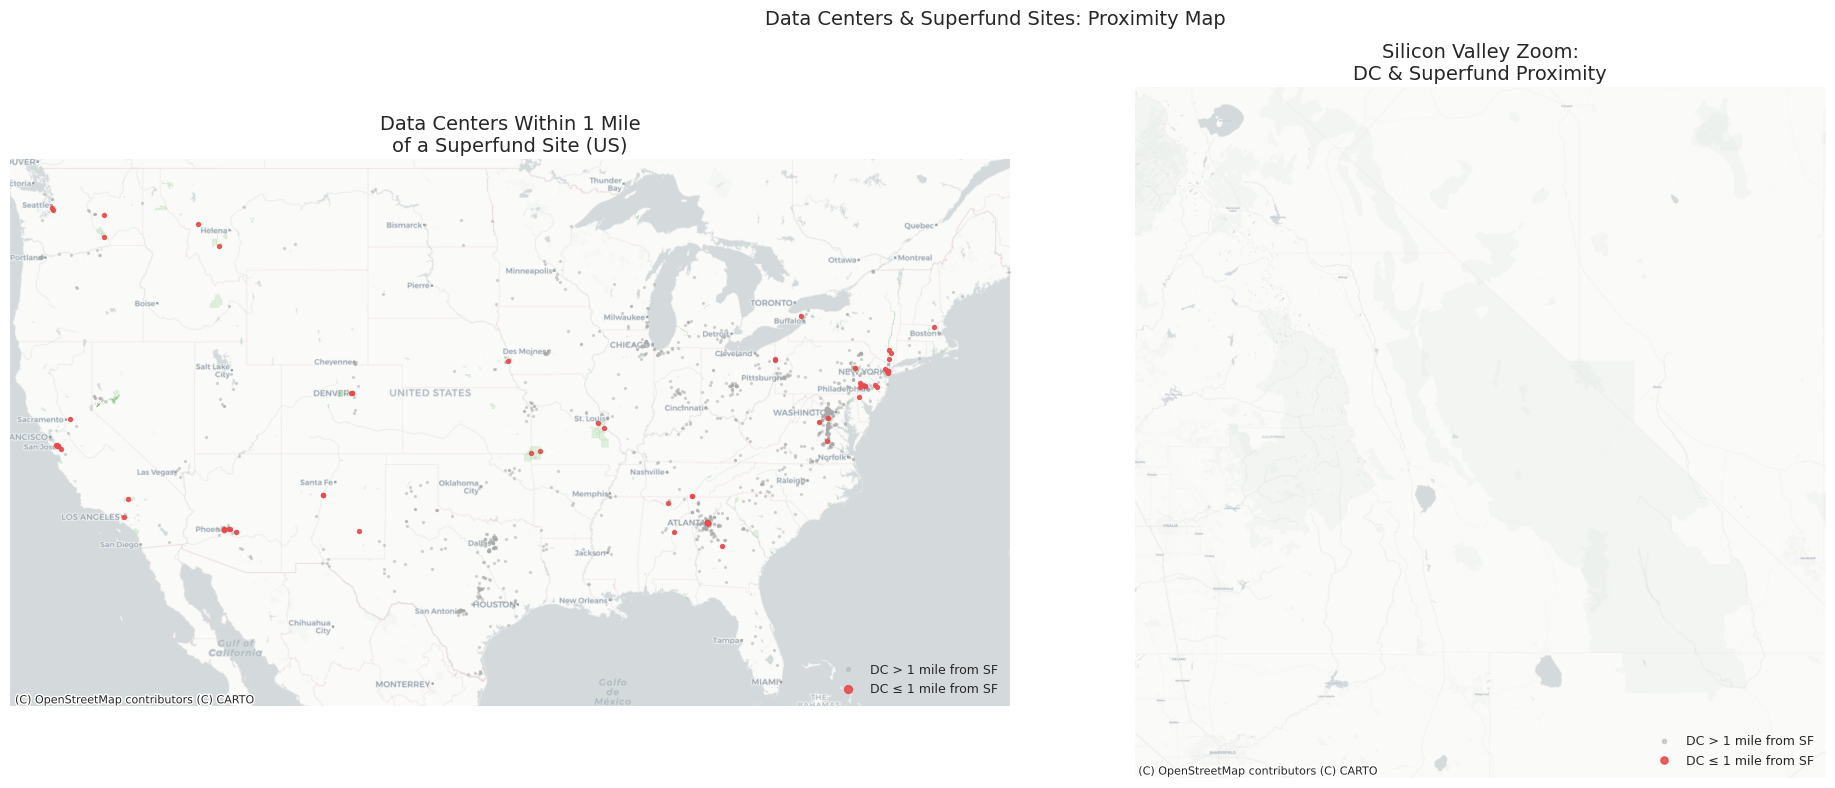

In [76]:
# ══════════════════════════════════════════════════════════════════
# BEAT 6: Map
# ══════════════════════════════════════════════════════════════════

import contextily as ctx

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Data Centers & Superfund Sites: Proximity Map", fontsize=14)

# ── Reproject to Web Mercator for basemap ─────────────────────────
dc_web = dc_df[~dc_df["invalid_coords"]].to_crs(epsg=3857)
sf_web = sf_df[sf_df["geometry"].notnull()].to_crs(epsg=3857)

# ── Create near_sf_1mi column if not present ──────────────────────
dc_web["near_sf_1mi"] = dc_df["near_sf_1mi"]

# ── Continental US bounds ─────────────────────────────────────────
CONUS = {
    "minx": -13884029, "maxx": -7453304,
    "miny":  2818228,  "maxy":  6335621,
}

# ── 6a: Full US map colored by near_sf_1mi ────────────────────────
# SF polygons first
sf_web.plot(
    ax=axes[0],
    color=COLORS["superfund"],
    alpha=0.2,
    linewidth=0.2,
    edgecolor=COLORS["superfund"],
)

# DCs not near SF
dc_web[dc_web["near_sf_1mi"] == 0].plot(
    ax=axes[0],
    color=COLORS["neutral"],
    markersize=2,
    alpha=0.4,
    label="DC > 1 mile from SF",
)

# DCs near SF — plot on top, larger
dc_web[dc_web["near_sf_1mi"] == 1].plot(
    ax=axes[0],
    color=COLORS["highlight"],
    markersize=8,
    alpha=0.9,
    label="DC ≤ 1 mile from SF",
    zorder=5,
)

axes[0].set_xlim(CONUS["minx"], CONUS["maxx"])
axes[0].set_ylim(CONUS["miny"], CONUS["maxy"])
axes[0].set_title("Data Centers Within 1 Mile\nof a Superfund Site (US)")
axes[0].set_axis_off()
axes[0].legend(loc="lower right", markerscale=2, fontsize=9)

try:
    ctx.add_basemap(
        axes[0],
        source=ctx.providers.CartoDB.Positron,
        zoom=5,
    )
except Exception as e:
    print(f"  ⚠  Basemap unavailable: {e}")

# ── 6b: California zoom — Silicon Valley cluster ──────────────────
# CA bounds in Web Mercator
CA_BOUNDS = {
    "minx": -13300000, "maxx": -12900000,
    "miny":   4200000, "maxy":   4600000,
}

sf_web.plot(
    ax=axes[1],
    color=COLORS["superfund"],
    alpha=0.3,
    linewidth=0.5,
    edgecolor=COLORS["superfund"],
)

dc_web[dc_web["near_sf_1mi"] == 0].plot(
    ax=axes[1],
    color=COLORS["neutral"],
    markersize=4,
    alpha=0.5,
    label="DC > 1 mile from SF",
)

dc_web[dc_web["near_sf_1mi"] == 1].plot(
    ax=axes[1],
    color=COLORS["highlight"],
    markersize=12,
    alpha=0.9,
    label="DC ≤ 1 mile from SF",
    zorder=5,
)

axes[1].set_xlim(CA_BOUNDS["minx"], CA_BOUNDS["maxx"])
axes[1].set_ylim(CA_BOUNDS["miny"], CA_BOUNDS["maxy"])
axes[1].set_title("Silicon Valley Zoom:\nDC & Superfund Proximity")
axes[1].set_axis_off()
axes[1].legend(loc="lower right", markerscale=1.5, fontsize=9)

try:
    ctx.add_basemap(
        axes[1],
        source=ctx.providers.CartoDB.Positron,
        zoom=10,
    )
except Exception as e:
    print(f"  ⚠  Basemap unavailable: {e}")

plt.tight_layout()
plt.show()

In [77]:
# Find Georgia DCs within 1 mile to center the zoom
ga_near = dc_df[
    (dc_df["state"] == "GA") &
    (dc_df["near_sf_1mi"] == 1)
][["facility_name", "city", "lat", "long", "status_group"]]
print(ga_near)

# Get bounds to set zoom
print(f"\nLat range: {ga_near['lat'].min():.4f} → {ga_near['lat'].max():.4f}")
print(f"Lon range: {ga_near['long'].min():.4f} → {ga_near['long'].max():.4f}")

                                          facility_name           city  \
84                                     10 Forsyth St NW        Atlanta   
87        AT&T Southern Bell Telephone Company Building        Atlanta   
89                                ATL2 Colo Data Center        Atlanta   
90                                              Atlanta        Atlanta   
91                                          Atlanta AT1        Atlanta   
93                                        Atlanta ATL13        Atlanta   
94                                        Atlanta ATL14        Atlanta   
95                                    Atlanta Metro DC1        Atlanta   
96                                    Atlanta Metro DC2        Atlanta   
97                                    Atlanta Metro DC3        Atlanta   
98                                    Atlanta Metro DC4        Atlanta   
99                                    ATLDC 55 Marietta        Atlanta   
100   CODA at Tech Sq (GA Tech High Pe

In [78]:
# ── Summary stats ──────────────────────────────────────────────────
print("DCs within 1 mile of SF site by state:")
near_by_state = (
    dc_df[dc_df["near_sf_1mi"] == 1]
    .groupby("state")
    .size()
    .sort_values(ascending=False)
)
print(near_by_state)

print(f"\nDCs within 1 mile by status group and state:")
print(
    dc_df[dc_df["near_sf_1mi"] == 1]
    .groupby(["state", "status_group"])
    .size()
    .unstack(fill_value=0)
)

DCs within 1 mile of SF site by state:
state
GA    22
CA    11
PA     9
NY     9
AZ     7
WA     4
NM     4
NJ     4
MO     4
VA     4
CO     3
AL     2
MT     2
TN     2
DE     1
MA     1
NE     1
dtype: int64

DCs within 1 mile by status group and state:
status_group  In Pipeline  Inactive  Operating
state                                         
AL                      1         0          1
AZ                      3         0          4
CA                      6         1          4
CO                      1         0          2
DE                      0         1          0
GA                      2         0         20
MA                      1         0          0
MO                      4         0          0
MT                      2         0          0
NE                      0         0          1
NJ                      1         1          2
NM                      1         0          3
NY                      3         0          6
PA                      3         1   

In [79]:
# Calculate Web Mercator bounds from lat/long
import geopandas as gpd
from shapely.geometry import box

# Atlanta cluster with padding
atl_bbox = box(-84.45, 33.73, -84.35, 33.81)
atl_gdf  = gpd.GeoDataFrame(geometry=[atl_bbox], crs="EPSG:4326")
atl_web  = atl_gdf.to_crs(epsg=3857)
bounds   = atl_web.total_bounds  # minx, miny, maxx, maxy
print(f"Atlanta Web Mercator bounds: {bounds}")

Atlanta Web Mercator bounds: [-9400930.99749195  3992604.9855232  -9389799.04841262  4003318.11159247]


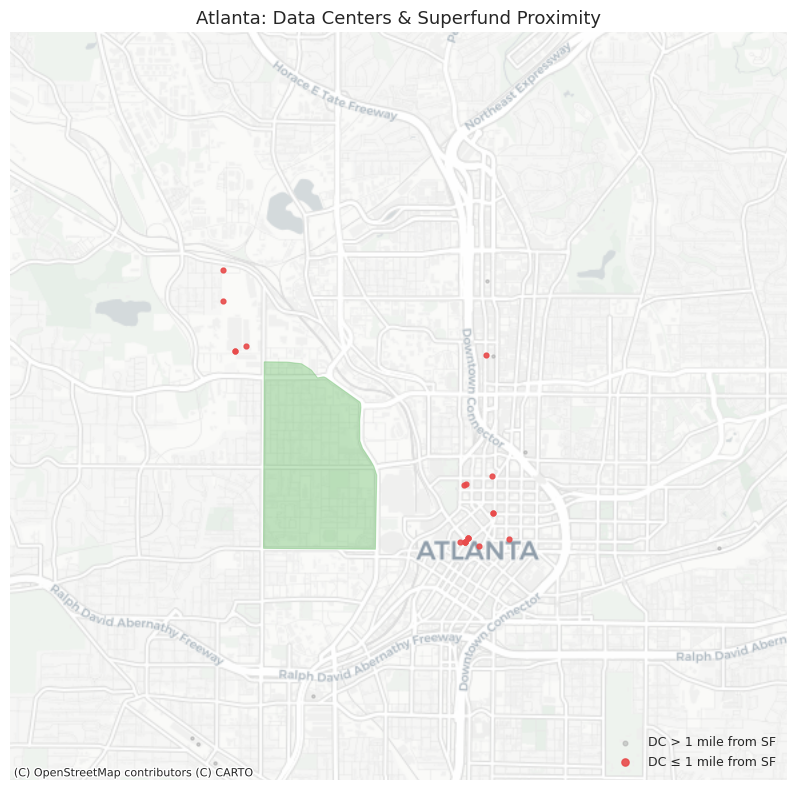

In [80]:
# ── Standalone Atlanta zoom ───────────────────────────────────────
import contextily as ctx

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

ATL_BOUNDS = {
    "minx": -9400930,
    "maxx": -9389799,
    "miny":  3992604,
    "maxy":  4003318,
}

dc_web = dc_df[~dc_df["invalid_coords"]].to_crs(epsg=3857)
sf_web = sf_df[sf_df["geometry"].notnull()].to_crs(epsg=3857)

sf_web.plot(
    ax=ax,
    color=COLORS["superfund"],
    alpha=0.4,
    linewidth=0.8,
    edgecolor=COLORS["superfund"],
)

dc_web[dc_web["near_sf_1mi"] == 0].plot(
    ax=ax,
    color=COLORS["neutral"],
    markersize=5,
    alpha=0.5,
    label="DC > 1 mile from SF",
)

dc_web[dc_web["near_sf_1mi"] == 1].plot(
    ax=ax,
    color=COLORS["highlight"],
    markersize=12,
    alpha=0.9,
    label="DC ≤ 1 mile from SF",
    zorder=5,
)

ax.set_xlim(ATL_BOUNDS["minx"], ATL_BOUNDS["maxx"])
ax.set_ylim(ATL_BOUNDS["miny"], ATL_BOUNDS["maxy"])
ax.set_title("Atlanta: Data Centers & Superfund Proximity", fontsize=13)
ax.set_axis_off()
ax.legend(loc="lower right", markerscale=1.5, fontsize=9)

try:
    ctx.add_basemap(
        ax,
        source=ctx.providers.CartoDB.Positron,
        zoom=13,
    )
except Exception as e:
    print(f"  ⚠  Basemap unavailable: {e}")

plt.tight_layout()
plt.show()

## Beat 6: Proximity Map (Continental US)
## Beat 7: Atlanta Zoom

### What we explored:
- Continental US map of DC points colored by `near_sf_1mi` over SF polygons
- Zoom map of Atlanta showing the DC cluster adjacent to a SF polygon

### Continental US map findings:
Red dots (DCs within 1 mile of SF) are visible across the US with notable
clusters in:
- Northeast corridor (NY/NJ/PA/DC) — dense overlap of both datasets
- Atlanta — largest single-city cluster
- Silicon Valley — semiconductor legacy sites
- Isolated points in Montana, New Mexico, Arizona, Missouri

The map confirms that SF-adjacent DC development is not confined to one
region — it is a national pattern.

### Atlanta zoom findings:
The Atlanta map reveals a large SF polygon in west Atlanta with multiple
red dots (DCs within 1 mile) clustered around its eastern boundary near
the downtown corridor. Two distinct clusters are visible:
- West cluster: Metro DC1-4 sites near the SF polygon boundary
- East cluster: Dense downtown corridor including AT&T, Equinix, Cogent,
  and multiple colocation facilities along Forsyth St/Downtown Connector

**Pending investigation:** The identity of the Atlanta SF polygon is not
yet confirmed — the query against Final NPL sites returned empty, suggesting
it may be a Deleted (D) or non-Final NPL site. If Deleted, this would be
a critical finding given the EPA's policy of accelerating SF site deletions
to facilitate data center development.

### Zoom bounds used:
Atlanta Web Mercator bounds:
`[-9400930, -9389799, 3992604, 4003318]` (EPSG:3857)
Basemap: CartoDB Positron, zoom=13

## Next notebook:
`04_causal_analysis.ipynb` — formal hypothesis testing and causal inference
using DoWhy and EconML, reading from `data/processed/dc_causal.parquet`
produced by `src/build_causal_features.py`.